In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import os
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              classification_report, roc_auc_score)

data_path   = r"C:\Users\lenovo\Desktop\Projects\Network-IDS\data"
models_path = r"C:\Users\lenovo\Desktop\Projects\Network-IDS\models"
reports_path = r"C:\Users\lenovo\Desktop\Projects\Network-IDS\reports"
os.makedirs(reports_path, exist_ok=True)

print("Imports done")

Imports done


In [2]:
X_test  = pd.read_csv(os.path.join(data_path, "X_test.csv"))
y_test  = pd.read_csv(os.path.join(data_path, "y_test.csv")).squeeze()

with open(os.path.join(models_path, "random_forest.pkl"), "rb") as f:
    rf_model = pickle.load(f)
with open(os.path.join(models_path, "logistic_regression.pkl"), "rb") as f:
    lr_model = pickle.load(f)

rf_preds = rf_model.predict(X_test)
lr_preds = lr_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
lr_proba = lr_model.predict_proba(X_test)[:, 1]

print("Models and data loaded")
print(f"Test set: {X_test.shape}")

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    1.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    2.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.9s


Models and data loaded
Test set: (305636, 80)


[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    2.3s finished


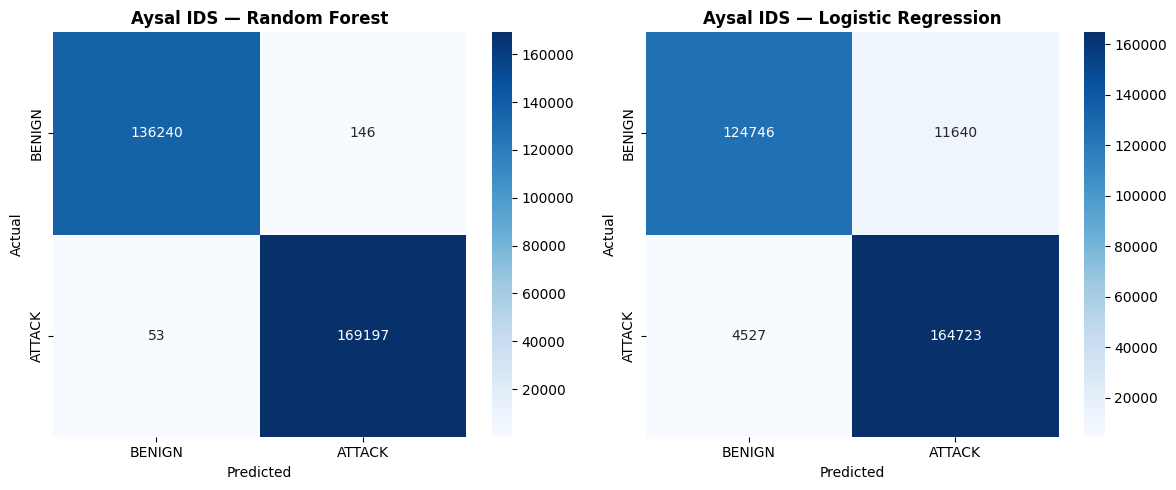

Saved to reports/confusion_matrices.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [rf_preds, lr_preds],
    ["Random Forest", "Logistic Regression"]
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["BENIGN", "ATTACK"],
                yticklabels=["BENIGN", "ATTACK"])
    ax.set_title(f"Aysal IDS — {title}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(os.path.join(reports_path, "confusion_matrices.png"), dpi=150)
plt.show()
print("Saved to reports/confusion_matrices.png")

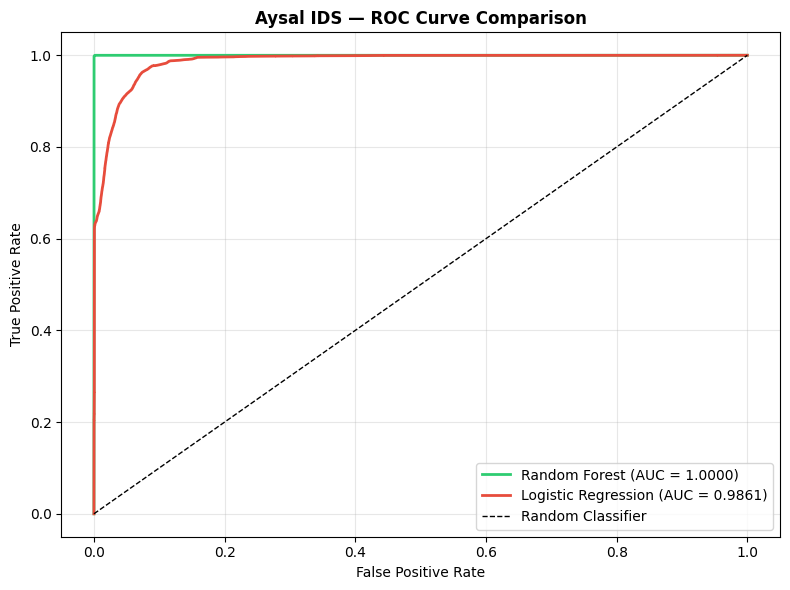

Saved to reports/roc_curve.png


In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

for proba, label, color in zip(
    [rf_proba, lr_proba],
    ["Random Forest", "Logistic Regression"],
    ["#2ecc71", "#e74c3c"]
):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{label} (AUC = {auc_score:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Aysal IDS — ROC Curve Comparison", fontsize=12, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(reports_path, "roc_curve.png"), dpi=150)
plt.show()
print("Saved to reports/roc_curve.png")

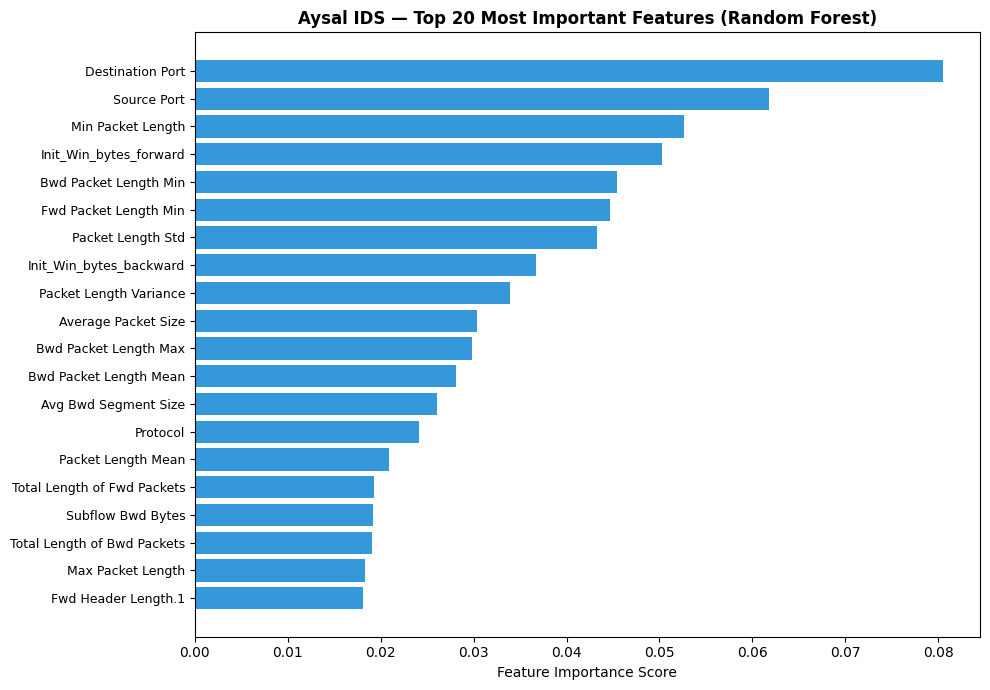

Saved to reports/feature_importance.png


In [5]:
feature_names = X_test.columns.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    range(20),
    importances[indices][::-1],
    color="#3498db"
)
ax.set_yticks(range(20))
ax.set_yticklabels([feature_names[i] for i in indices][::-1], fontsize=9)
ax.set_xlabel("Feature Importance Score")
ax.set_title("Aysal IDS — Top 20 Most Important Features (Random Forest)",
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(reports_path, "feature_importance.png"), dpi=150)
plt.show()
print("Saved to reports/feature_importance.png")

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=" * 60)
print("        AYSAL IDS — FINAL RESULTS SUMMARY")
print("=" * 60)

for preds, proba, name in zip(
    [rf_preds, lr_preds],
    [rf_proba, lr_proba],
    ["Random Forest", "Logistic Regression"]
):
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec  = recall_score(y_test, preds)
    f1   = f1_score(y_test, preds)
    auc  = roc_auc_score(y_test, proba)
    print(f"\n  {name}")
    print(f"    Accuracy  : {acc:.4f}")
    print(f"    Precision : {prec:.4f}")
    print(f"    Recall    : {rec:.4f}")
    print(f"    F1-Score  : {f1:.4f}")
    print(f"    ROC-AUC   : {auc:.4f}")

print("\n" + "=" * 60)
print("  Reports saved to reports/")
print("  Models saved to models/")
print("=" * 60)

        AYSAL IDS — FINAL RESULTS SUMMARY

  Random Forest
    Accuracy  : 0.9993
    Precision : 0.9991
    Recall    : 0.9997
    F1-Score  : 0.9994
    ROC-AUC   : 1.0000

  Logistic Regression
    Accuracy  : 0.9471
    Precision : 0.9340
    Recall    : 0.9733
    F1-Score  : 0.9532
    ROC-AUC   : 0.9861

  Reports saved to reports/
  Models saved to models/
